# 01 — Data prep, descriptors, and exploratory analysis

 * Target: human 5-HT2A receptor ([UniProt **P28223**](https://www.uniprot.org/uniprotkb/P28223/entry)), data from [Papyrus++](https://link.springer.com/article/10.1186/s13321-022-00672-x) 05.7
 * Reference sets: ChEMBL mTOR IC50, DrugBank, ZINC random
 * Active/inactive threshold: pChEMBL $\ge$ 7

In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

USER_DIR = Path.cwd().resolve()
REF_DIR  = USER_DIR.parent / "data"
DATA_DIR = USER_DIR / "data"
PROC     = DATA_DIR / "processed"
PAPYRUS_CACHE = DATA_DIR / "papyrus_cache"
PROC.mkdir(parents=True, exist_ok=True)
os.environ["PYSTOW_HOME"] = str(PAPYRUS_CACHE)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 80)

PAPYRUS_VERSION   = "05.7"
TARGET_ACCESSION  = "P28223"
PCHEMBL_CUTOFF    = 7.0
RANDOM_STATE      = 42

## Data loading and standardization
 * Papyrus loaded using [papyrus-scripts](https://github.com/OlivierBeq/Papyrus-scripts)
    * uses PyStow - PyStow home directory has been changed and the new location placed into gitignore
    * dataset filtered to target
    * saved as Parquet, also in gitignore

In [2]:
raw_parquet = PROC / f"papyrus_{PAPYRUS_VERSION}_pp_{TARGET_ACCESSION}.parquet"
if raw_parquet.exists():
    raw = pd.read_parquet(raw_parquet)
else:
    from papyrus_scripts import PapyrusDataset
    raw = (PapyrusDataset(version=PAPYRUS_VERSION, plusplus=True, is3d=False)
           .keep_accession([TARGET_ACCESSION]).to_dataframe())
    raw.to_parquet(raw_parquet, index=False)
print(f"Raw Papyrus rows: {len(raw):,}")

display(raw.head())

Raw Papyrus rows: 3,329


,Activity_ID,Quality,source,CID,SMILES,connectivity,InChIKey,InChI,InChI_AuxInfo,target_id,TID,accession,Protein_Type,AID,doc_id,Year,all_doc_ids,all_years,type_IC50,type_EC50,type_KD,type_Ki,type_other,Activity_class,relation,pchembl_value,pchembl_value_Mean,pchembl_value_StdDev,pchembl_value_SEM,pchembl_value_N,pchembl_value_Median,pchembl_value_MAD
0,AAELEHAFAYIZRH_on_P28223_WT,High,ChEMBL34,ChEMBL:CHEMBL3950977;ChEMBL:CHEMBL3946995,O=C(NC1CCC(CCN2CCN(c3nsc4ccccc34)CC2)CC1)c1ccco1,AAELEHAFAYIZRH,AAELEHAFAYIZRH-UHFFFAOYSA-N,InChI=1S/C24H30N4O2S/c29-24(21-5-3-17-30-21)25-19-9-7-18(8-10-19)11-12-27-13...,"AuxInfo=1/1/N:20,19,29,21,28,18,6,25,5,26,8,9,11,24,12,23,30,7,4,22,27,17,14...",P28223_WT,ChEMBL:CHEMBL224,P28223,WT,CHEMBL3872758,PMID:27487565,2016.0,PMID:27487565,2016,0,0,0,1,NaN,NaN,=,9.72;9.64,9.680,0.056569,0.040,2.0,9.680,0.040
1,AAELFMMXNFMCCW_on_P28223_WT,High,ChEMBL34,ChEMBL:CHEMBL187888,CC1CNCC2Cc3ccc(C#N)cc3N12,AAELFMMXNFMCCW,AAELFMMXNFMCCW-UHFFFAOYSA-N,"InChI=1S/C13H15N3/c1-9-7-15-8-12-5-11-3-2-10(6-14)4-13(11)16(9)12/h2-4,9,12,...","AuxInfo=1/0/N:1,10,9,14,7,12,3,5,2,11,8,6,15,13,4,16/rA:16CCCNCCCCCCCCNCCN/r...",P28223_WT,ChEMBL:CHEMBL224,P28223,WT,CHEMBL829616,PMID:15975787,2005.0,PMID:15975787,2005,0,0,0,1,NaN,NaN,=,6.96,6.960,0.000000,0.000,1.0,6.960,0.000
2,AAPCMUAAQFZHRZ_on_P28223_WT,High,ChEMBL34,ChEMBL:CHEMBL3697990;ChEMBL:CHEMBL3697989,CC(C)C(O)C(=O)NC1CCC(CCN2CCN(c3cccc4c3OCO4)CC2)CC1,AAPCMUAAQFZHRZ,AAPCMUAAQFZHRZ-UHFFFAOYSA-N,InChI=1S/C24H37N3O4/c1-17(2)22(28)24(29)25-19-8-6-18(7-9-19)10-11-26-12-14-2...,"AuxInfo=1/1/N:1,3,21,20,22,11,30,10,31,13,14,16,29,17,28,26,2,12,9,19,23,4,2...",P28223_WT,ChEMBL:CHEMBL224,P28223,WT,CHEMBL3707798,PATENT:US8722683B2,2014.0,PATENT:US8722683B2,2014,0,0,0,1,NaN,NaN,=,7.65;7.46,7.555,0.134350,0.095,2.0,7.555,0.095
3,AAQUEQYOKSKIDA_on_P28223_WT,High,ChEMBL34,ChEMBL:CHEMBL4860754,COc1ccccc1N1CCN(CCCCCN2C(=O)c3ccccc3S2(=O)=O)CC1,AAQUEQYOKSKIDA,AAQUEQYOKSKIDA-UHFFFAOYSA-N,InChI=1S/C23H29N3O4S/c1-30-21-11-5-4-10-20(21)25-17-15-24(16-18-25)13-7-2-8-...,"AuxInfo=1/0/N:1,15,23,6,5,24,14,16,22,7,4,25,13,17,11,30,10,31,21,8,3,26,19,...",P28223_WT,ChEMBL:CHEMBL224,P28223,WT,CHEMBL4821480,PMID:33839253,2021.0,PMID:33839253,2021,0,0,0,1,NaN,NaN,=,6.23,6.230,0.000000,0.000,1.0,6.230,0.000
4,AARWRAFDYZSYPD_on_P28223_WT,High,ChEMBL34,ChEMBL:CHEMBL373873,Cc1c(C(=O)NCCCCN2CCN(c3cccc(Cl)c3Cl)CC2)nnn1Cc1ccccc1,AARWRAFDYZSYPD,AARWRAFDYZSYPD-UHFFFAOYSA-N,InChI=1S/C25H30Cl2N6O/c1-19-24(29-30-33(19)18-20-8-3-2-4-9-20)25(34)28-12-5-...,"AuxInfo=1/1/N:1,32,31,33,8,9,17,30,34,18,16,7,10,12,24,13,23,28,2,29,19,15,2...",P28223_WT,ChEMBL:CHEMBL224,P28223,WT,CHEMBL3614295,PMID:26299826,2015.0,PMID:26299826,2015,0,0,0,1,NaN,NaN,=,8.13,8.130,0.000000,0.000,1.0,8.130,0.000


In [17]:
std_types = ["type_IC50", "type_EC50", "type_KD", "type_Ki"]
has_std = pd.concat(
    [raw[c].astype(str).str.contains("1", na=False) for c in std_types], axis=1
).any(axis=1)

ht2a = raw[has_std & raw["pchembl_value_Mean"].notna()].copy()
ht2a["active"] = (ht2a["pchembl_value_Mean"] >= PCHEMBL_CUTOFF).astype(int)
print(f"After type+pchembl filter: {len(ht2a):,} rows "
      f"({ht2a['active'].mean():.1%} active @ pChEMBL >= {PCHEMBL_CUTOFF})")

After type+pchembl filter: 3,329 rows (53.4% active @ pChEMBL >= 7.0)


In [4]:
from rdkit import Chem, RDLogger
from rdkit.Chem.MolStandardize import rdMolStandardize
RDLogger.DisableLog("rdApp.*")

_lfc      = rdMolStandardize.LargestFragmentChooser()
_uncharger = rdMolStandardize.Uncharger()

def standardize_smiles(smi):
    """Canonical SMILES of largest, neutralized fragment, or None on failure."""
    if not isinstance(smi, str) or not smi:
        return None
    try:
        m = Chem.MolFromSmiles(smi)
        if m is None: return None
        m = rdMolStandardize.Cleanup(m)
        m = _lfc.choose(m)
        m = _uncharger.uncharge(m)
        return Chem.MolToSmiles(m)
    except Exception:
        return None

def to_inchikey(smi):
    m = Chem.MolFromSmiles(smi) if isinstance(smi, str) else None
    return Chem.MolToInchiKey(m) if m else None

In [5]:
ht2a["smiles_std"] = ht2a["SMILES"].map(standardize_smiles)
ht2a = ht2a[ht2a["smiles_std"].notna()].copy()
ht2a["inchikey"] = ht2a["smiles_std"].map(to_inchikey)
ht2a = ht2a.drop_duplicates("inchikey").reset_index(drop=True)
print(f"Curated 5-HT2A set: {len(ht2a):,} compounds "
      f"({ht2a['active'].mean():.1%} active)")

Curated 5-HT2A set: 3,329 compounds (53.4% active)


This is an expected result, since Papyrus is already curated and QSAR-ready. 

---------------------

In [6]:
def curate_smiles(smiles_iterable):
    out = pd.DataFrame({"smiles_raw": list(smiles_iterable)})
    out["smiles_std"] = out["smiles_raw"].map(standardize_smiles)
    out = out[out["smiles_std"].notna()].copy()
    out["inchikey"] = out["smiles_std"].map(to_inchikey)
    return out.drop_duplicates("inchikey").reset_index(drop=True)

def load_mtor():
    d = pd.read_csv(REF_DIR / "chembl_mtor_ic50.csv", sep=";",
                    on_bad_lines="skip", low_memory=False)
    return d["Smiles"].dropna().tolist()

def load_drugbank():
    suppl = Chem.SDMolSupplier(str(REF_DIR / "drugbank.sdf"), removeHs=True)
    return [Chem.MolToSmiles(m) for m in suppl if m is not None]

# to keep sets balanced in size, we sample Zinc 
def load_zinc(n_sample=5000):
    d = pd.read_csv(REF_DIR / "zinc_random_structures.txt", sep=r"\s+",
                    engine="python")
    if len(d) > n_sample:
        d = d.sample(n_sample, random_state=RANDOM_STATE)
    return d["SMILES"].dropna().tolist()

ref_sets = {
    "mTOR (ChEMBL)":  curate_smiles(load_mtor()),
    "DrugBank":       curate_smiles(load_drugbank()),
    "ZINC (random)":  curate_smiles(load_zinc()),
}
for k, v in ref_sets.items():
    print(f"  {k:18s} {len(v):,}")

  mTOR (ChEMBL)      4,166
  DrugBank           6,942
  ZINC (random)      5,000


In [7]:
sets_df = pd.concat(
    [ht2a.assign(set="5-HT2A")[["smiles_std", "inchikey", "set"]]] +
    [d.assign(set=name)[["smiles_std", "inchikey", "set"]]
     for name, d in ref_sets.items()],
    ignore_index=True,
)
print(sets_df["set"].value_counts())
#display(sets_df.head())

set
DrugBank         6942
ZINC (random)    5000
mTOR (ChEMBL)    4166
5-HT2A           3329
Name: count, dtype: int64


In [8]:
from rdkit.Chem import Descriptors, Crippen, rdMolDescriptors

DESCRIPTORS = {
    "MW":         Descriptors.MolWt,
    "LogP":       Crippen.MolLogP,
    "TPSA":       Descriptors.TPSA,
    "HBD":        rdMolDescriptors.CalcNumHBD,
    "HBA":        rdMolDescriptors.CalcNumHBA,
    "RotB":       rdMolDescriptors.CalcNumRotatableBonds,
    "NAromRings": rdMolDescriptors.CalcNumAromaticRings,
    "NumHeteroatoms": rdMolDescriptors.CalcNumHeteroatoms,
}

def calc_descs(smi):
    m = Chem.MolFromSmiles(smi)
    if m is None: return [np.nan] * len(DESCRIPTORS)
    return [fn(m) for fn in DESCRIPTORS.values()]

desc_arr = np.array([calc_descs(s) for s in sets_df["smiles_std"]])
analysis = pd.concat(
    [sets_df.reset_index(drop=True),
     pd.DataFrame(desc_arr, columns=DESCRIPTORS.keys())],
    axis=1,
).dropna(subset=list(DESCRIPTORS)).reset_index(drop=True)

print(analysis.groupby("set")[list(DESCRIPTORS)].median().round(2))
#display(analysis.head())

                   MW  LogP    TPSA  HBD  HBA  RotB  NAromRings  \
set                                                               
5-HT2A         417.55  3.98   51.29  1.0  4.0   6.0         2.0   
DrugBank       324.42  2.01   83.55  2.0  4.0   4.0         1.0   
ZINC (random)  390.55  2.27   82.46  2.0  5.0   6.0         1.0   
mTOR (ChEMBL)  460.54  3.12  101.50  2.0  7.0   5.0         3.0   

               NumHeteroatoms  
set                            
5-HT2A                    6.0  
DrugBank                  6.0  
ZINC (random)             8.0  
mTOR (ChEMBL)             9.0  


Dropped for plotting (MW ≥ 800): {'DrugBank': 207, 'ZINC (random)': 0, 'mTOR (ChEMBL)': 14, '5-HT2A': 0}


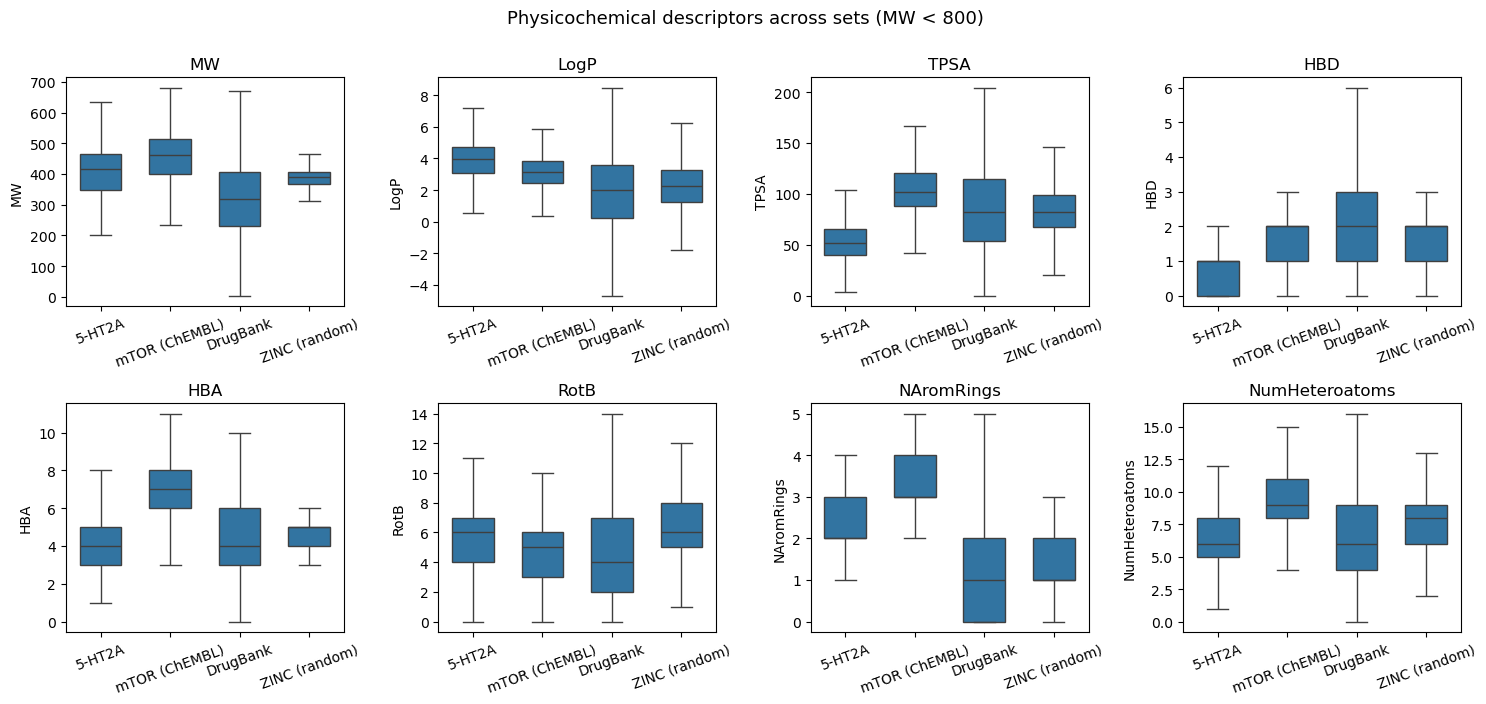

In [9]:
# DrugBank dominates the scale of each box plot, rendering the plot uninformative, so I drop MW >= 800 
plot_df = analysis[analysis["MW"] < 800].copy()

dropped = (analysis["set"].value_counts() - plot_df["set"].value_counts()).fillna(0).astype(int)
print(f"Dropped for plotting (MW ≥ 800): {dropped.to_dict()}")

fig, axes = plt.subplots(2, 4, figsize=(15, 7))
set_order = ["5-HT2A", "mTOR (ChEMBL)", "DrugBank", "ZINC (random)"]
for ax, d in zip(axes.flat, DESCRIPTORS):
    sns.boxplot(data=plot_df, x="set", y=d, ax=ax, order=set_order,
                showfliers=False, width=0.6)
    ax.set_title(d); ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=20)
fig.suptitle("Physicochemical descriptors across sets (MW < 800)",
             y=1.00, fontsize=13)
fig.tight_layout()
#fig.savefig(PROC / "viz_descriptor_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

## Scaffold analysis

               n_compounds  n_scaffolds  scaf_diversity
set                                                    
5-HT2A                3329         1352           0.406
DrugBank              6942         3322           0.552
ZINC (random)         5000         4504           0.905
mTOR (ChEMBL)         4166         1524           0.366

Top 5 scaffolds in 5-HT2A actives+inactives:
scaffold
O=C(NCCCN1CCN(c2ccccc2)CC1)c1cn(-c2ccccc2)cn1    71
c1ccc(C2NCCc3c2[nH]c2ccccc32)cc1                 59
c1ccc2c(c1)CC1NCCc3cccc-2c31                     48
c1cc2c(c(N3CCN(CCC4CCCCC4)CC3)n1)CCO2            41
c1ccc(C2CC2)cc1                                  39
Name: count, dtype: int64


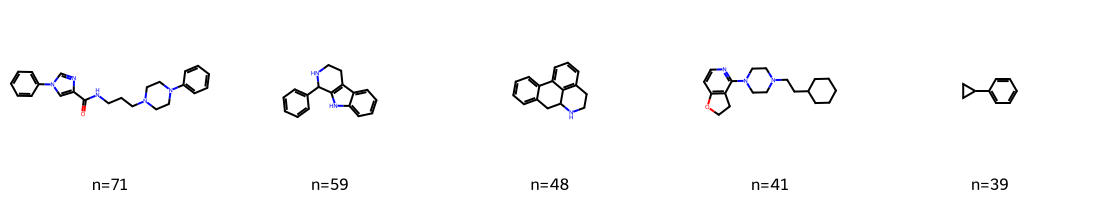

In [10]:
from rdkit.Chem.Scaffolds import MurckoScaffold
from rdkit.Chem import Draw

def scaffold_smiles(smi):
    m = Chem.MolFromSmiles(smi)
    if m is None: return None
    s = MurckoScaffold.GetScaffoldForMol(m)
    return Chem.MolToSmiles(s) if s.GetNumAtoms() else None

analysis["scaffold"] = analysis["smiles_std"].map(scaffold_smiles)
scaf_summary = (
    analysis.groupby("set")
            .agg(n_compounds=("smiles_std", "size"),
                 n_scaffolds=("scaffold", lambda s: s.dropna().nunique()),
                 scaf_diversity=("scaffold",
                                 lambda s: s.dropna().nunique() / max(s.dropna().size, 1)))
            .round(3)
)
print(scaf_summary)

# Top 5 scaffolds within the 5-HT2A set
top_scaf = (analysis[analysis["set"] == "5-HT2A"]["scaffold"]
            .value_counts().head(5))
print("\nTop 5 scaffolds in 5-HT2A actives+inactives:")
print(top_scaf)

top_mols = [Chem.MolFromSmiles(s) for s in top_scaf.index]
Draw.MolsToGridImage(
    top_mols,
    legends=[f"n={n}" for n in top_scaf.values],
    molsPerRow=5, subImgSize=(220, 200),
)

## Fingerprint visualization
 * Morgan fingerprints were used: radius=2, n_bits=2048
 * visualized using PCA and t-SNE (perplexity 40, Jaccard distance)


In [11]:
from rdkit.Chem import AllChem
from rdkit.DataStructs import ConvertToNumpyArray

def morgan_fp(smi, radius=2, n_bits=2048):
    m = Chem.MolFromSmiles(smi)
    if m is None: return None
    return AllChem.GetMorganFingerprintAsBitVect(m, radius, n_bits)

def fp_array(fp, n_bits=2048):
    arr = np.zeros((n_bits,), dtype=np.uint8)
    ConvertToNumpyArray(fp, arr)
    return arr

fps = [morgan_fp(s) for s in analysis["smiles_std"]]
keep = [fp is not None for fp in fps]
analysis = analysis.loc[keep].reset_index(drop=True)
fp_matrix = np.stack([fp_array(fp) for fp, k in zip(fps, keep) if k])
print(f"Fingerprint matrix: {fp_matrix.shape}")

Fingerprint matrix: (19437, 2048)


Embedding 17,437 compounds: {'DrugBank': 6942, 'mTOR (ChEMBL)': 4166, '5-HT2A': 3329, 'ZINC (random)': 3000}


c:\Users\Tadeas\anaconda3\envs\cdd\Lib\site-packages\pynndescent\pynndescent_.py:939: UserWarning: Failed to correctly find n_neighbors for some samples. Results may be less than ideal. Try re-running with different parameters.
  warn(
c:\Users\Tadeas\anaconda3\envs\cdd\Lib\site-packages\openTSNE\nearest_neighbors.py:530: UserWarning: `pynndescent` failed to find neighbors for some of the points. As a workaround, openTSNE considers all such points similar to each other, so they will likely form a cluster in the embedding. Run with verbose=True, to see indices of the failed points.
  warnings.warn(


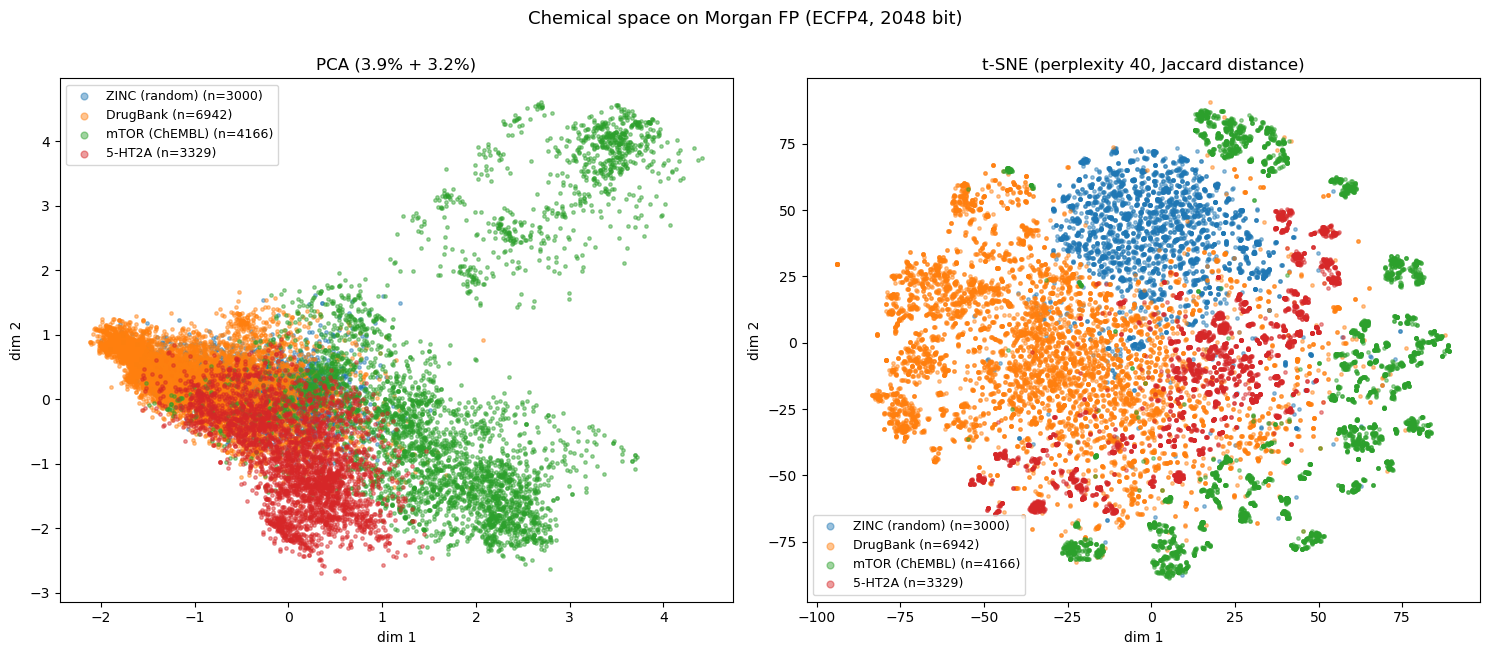

In [12]:
from openTSNE import TSNE

# Subsample ZINC so no single set dominates the embedding layout
rng = np.random.default_rng(RANDOM_STATE)
zinc_pos = np.where(analysis["set"].values == "ZINC (random)")[0]
if len(zinc_pos) > 3000:
    drop = rng.choice(zinc_pos, size=len(zinc_pos) - 3000, replace=False)
    viz_mask = np.ones(len(analysis), dtype=bool)
    viz_mask[drop] = False
else:
    viz_mask = np.ones(len(analysis), dtype=bool)

analysis_viz = analysis.loc[viz_mask].reset_index(drop=True)
fp_viz = fp_matrix[viz_mask]
print(f"Embedding {len(fp_viz):,} compounds: " + analysis_viz["set"].value_counts().to_dict().__repr__())

from sklearn.decomposition import PCA
pca = PCA(n_components=2, random_state=RANDOM_STATE)
pca_emb = pca.fit_transform(fp_viz)

tsne = TSNE(
    perplexity=40,
    metric="jaccard",
    neighbors="pynndescent",
    n_jobs=-1,
    random_state=RANDOM_STATE,
    n_iter=500,
)
tsne_emb = np.array(tsne.fit(fp_viz.astype(bool)))

fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))
order = ["ZINC (random)", "DrugBank", "mTOR (ChEMBL)", "5-HT2A"]
for ax, emb, title in [
    (axes[0], pca_emb,  f"PCA ({pca.explained_variance_ratio_[0]:.1%} + "
                        f"{pca.explained_variance_ratio_[1]:.1%})"),
    (axes[1], tsne_emb, "t-SNE (perplexity 40, Jaccard distance)"),
]:
    for name in order:
        d = analysis_viz["set"] == name
        ax.scatter(emb[d, 0], emb[d, 1], s=6, alpha=0.45, label=f"{name} (n={d.sum()})")
    ax.set_xlabel("dim 1"); ax.set_ylabel("dim 2"); ax.set_title(title)
    ax.legend(markerscale=2, loc="best", fontsize=9)
fig.suptitle("Chemical space on Morgan FP (ECFP4, 2048 bit)", y=1.00, fontsize=13)
fig.tight_layout()
fig.savefig(PROC / "viz_chemspace_pca_tsne.png", dpi=150, bbox_inches="tight")
plt.show()

## Within-set chemical diversity
 * using pairwise Tanimoto on Morgan FPs

                n_pairs   mean  median    p95
5-HT2A         124750.0  0.157   0.140  0.300
mTOR (ChEMBL)  124750.0  0.172   0.141  0.419
DrugBank       124750.0  0.087   0.081  0.169
ZINC (random)  124750.0  0.136   0.134  0.202


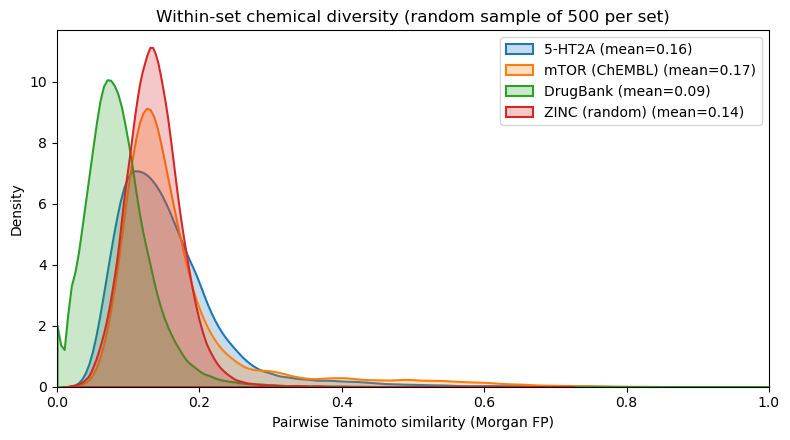

In [13]:
def pairwise_tanimoto_self(fps):
    """Upper-triangle Tanimoto similarities for a single fingerprint matrix."""
    q = fps.astype(np.uint32)
    inter = q @ q.T
    s = q.sum(axis=1)
    union = s[:, None] + s[None, :] - inter
    sim = inter / np.maximum(union, 1)
    iu = np.triu_indices_from(sim, k=1)
    return sim[iu]

SAMPLE_N = 500   # 125k pairs per set, enough for distribution shape
rng = np.random.default_rng(RANDOM_STATE)
sim_dist = {}
for name in ["5-HT2A", "mTOR (ChEMBL)", "DrugBank", "ZINC (random)"]:
    pos = np.where(analysis["set"].values == name)[0]
    if len(pos) > SAMPLE_N:
        pos = rng.choice(pos, SAMPLE_N, replace=False)
    sim_dist[name] = pairwise_tanimoto_self(fp_matrix[pos])

summary = pd.DataFrame({
    name: {"n_pairs": len(s), "mean": s.mean(), "median": np.median(s), "p95": np.quantile(s, 0.95)}
    for name, s in sim_dist.items()
}).T.round(3)
print(summary)

fig, ax = plt.subplots(figsize=(8, 4.5))
for name, sims in sim_dist.items():
    sns.kdeplot(sims, ax=ax, label=f"{name} (mean={sims.mean():.2f})",
                fill=True, alpha=0.25, linewidth=1.5, clip=(0, 1))
ax.set_xlabel("Pairwise Tanimoto similarity (Morgan FP)")
ax.set_ylabel("Density")
ax.set_title(f"Within-set chemical diversity (random sample of {SAMPLE_N} per set)")
ax.set_xlim(0, 1)
ax.legend()
fig.tight_layout()
fig.savefig(PROC / "viz_within_set_similarity.png", dpi=150, bbox_inches="tight")
plt.show()

### Save results as Parquet

In [16]:
# - analysis_compounds: every set, descriptors, scaffolds, (no FPs, no PCA)
# - ht2a_modeling:      5-HT2A only, with the `active` label
# - fingerprints:       FP matrix + inchikeys (alignable to either above)
analysis.to_parquet(PROC / "analysis_compounds.parquet")
np.savez_compressed(PROC / "fingerprints.npz",
                    fps=fp_matrix,
                    inchikeys=analysis["inchikey"].values,
                    sets=analysis["set"].values)
ht2a[["inchikey", "smiles_std", "pchembl_value_Mean", "active"]].to_parquet(PROC / "5ht2a_modeling.parquet")

print("Saved:")
for p in [PROC / "analysis_compounds.parquet",
          PROC / "fingerprints.npz",
          PROC / "5ht2a_modeling.parquet"]:
    print(f"  {p.name}  ({p.stat().st_size/1e6:.1f} MB)")

Saved:
  analysis_compounds.parquet  (1.5 MB)
  fingerprints.npz  (1.7 MB)
  5ht2a_modeling.parquet  (0.1 MB)
